# Figure S5: TagBFP fusion

Notes:

1. Singlets
2. EF1a-Nb(EGFP)-anti-TagBFP-P2A-iRFP670-WPRE
2a. RNA transfect - 24 hpt
2b. DNA Transfect - 48 hpt
2c. At least 6 dpi

**Load packages**

In [1]:
import pandas as pd
import numpy as np
import re
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
import scipy


**Stat functions**

In [2]:
# Convert p-value to significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


# Function for drawing brackets
def add_sig_bracket(ax, x1, x2, y, h, p):
    
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        color='black',
        linewidth=1,
        clip_on=False
    )
    
    ax.text(
        (x1 + x2) / 2,
        y + h,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=9
    )


# Load data

Directories for all

In [3]:
# Directories 
figpath = rd.rootdir/'output'/'Figure_S3_blue' # Fig path 
datadir = rd.datadir /'data'/ 'attune'/"nat_attune" / "desNb-circuits" # Base dir for data files

Load in transfection data

In [4]:
# Transfection data
comp_path = datadir / '2025.12.11_DASIT-transfect-infect-comp' # Data path

comp_path_1 = comp_path / '2025.12.11_DASIT-transfect_1-2'

# Data path
comp_cache_path_1 = rd.rootdir/'output'/'Figure_S3_blue'/'data1.gzip'

if comp_cache_path_1.exists():
    df_transfect_1 = pd.read_parquet(comp_cache_path_1)

else: 

    rd.plot.plot_well_metadata(comp_path_1/'2025.12.11_DASIT-transfect_1-2.yaml')
    df_transfect_1 = rd.flow.load_csv_with_metadata(comp_path_1/'export_singlets', comp_path_1/'2025.12.11_DASIT-transfect_1-2.yaml')
    

    # Shorten df
    channel_list = ['experiment', 'modality', 'cond', 'rep', 'well', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'TagBFP-A', 'TagBFP-H', 'TagBFP-H.1', 'eGFP-H.1',]
    df_transfect_1 = df_transfect_1.loc[:, channel_list]

    # Save shortened df
    df_transfect_1.to_parquet(rd.outfile(comp_cache_path_1))

In [5]:
comp_path_2 = comp_path / '2025.12.17_DASIT-transfect_3'

# Data path
comp_cache_path_2 = rd.rootdir/'output'/'Figure_S3_blue'/'data2.gzip'

if comp_cache_path_2.exists():
    df_transfect_2 = pd.read_parquet(comp_cache_path_2)

else: 

    rd.plot.plot_well_metadata(comp_path_2/'2025.12.17_DASIT-transfect_3.yaml')
    df_transfect_2 = rd.flow.load_csv_with_metadata(comp_path_2/'export_singlets', comp_path_2/'2025.12.17_DASIT-transfect_3.yaml')
    

    # Shorten df
    channel_list = ['experiment', 'modality', 'cond', 'rep', 'well', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'TagBFP-A', 'TagBFP-H', 'TagBFP-H.1', 'eGFP-H.1',]
    df_transfect_2 = df_transfect_2.loc[:, channel_list]

    # Save shortened df
    df_transfect_2.to_parquet(rd.outfile(comp_cache_path_2))

In [6]:
# Transfection data
comp_path = datadir / '2025.12.11_DASIT-transfect-infect-comp' # Data path

comp_path_3 = comp_path / '2025.12.18_DASIT-transfect_4'

# Data path
comp_cache_path_3 = rd.rootdir/'output'/'Figure_S3_blue'/'data3.gzip'

if comp_cache_path_3.exists():
    df_transfect_3 = pd.read_parquet(comp_cache_path_3)

else: 

    rd.plot.plot_well_metadata(comp_path_3/'2025.12.18_DASIT-transfect_4.yaml')
    df_transfect_3 = rd.flow.load_csv_with_metadata(comp_path_3/'export_singlets', comp_path_3/'2025.12.18_DASIT-transfect_4.yaml')
    

    # Shorten df
    channel_list = ['experiment', 'modality', 'cond', 'rep', 'well', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'TagBFP-A', 'TagBFP-H', 'TagBFP-H.1', 'eGFP-H.1',]
    df_transfect_3 = df_transfect_3.loc[:, channel_list]

    # Save shortened df
    df_transfect_3.to_parquet(rd.outfile(comp_cache_path_3))

Load in transduction data

In [7]:
# Infection data
comp_cache_path_infect = rd.rootdir/'output'/'Figure_S3_blue'/'data_infect.gzip'

if comp_cache_path_infect.exists():
    df_comp_infect = pd.read_parquet(comp_cache_path_infect)

else: 

    print(comp_path)
    files = Path(comp_path/'2025.12.12_vDN193-196_6dpi'/'export_singlets').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        match = re.search('export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue
        
        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        cond = match.group('cond')
        rep = match.group('rep')

        if cond[:4] == 'Ctrl':
            modality = 'Ctrl'
        else:
            modality = 'lenti'

        if cond == 'lenti-desNb': cond = 'desNb'
        elif cond == 'lenti-wtNb': cond = 'wtNb'
        

        df['cond'] = cond
        df['rep'] = int(rep)
        df['modality'] = modality

        df_list.append(df)

    # Convert list of dfs into single df
    df_comp_infect = pd.concat(df_list, ignore_index=True)


    # Shorten df
    df_comp_infect.loc[:, 'experiment'] = 'comparison'
    df_comp_infect.loc[:, 'well'] = 'None'

    channel_list = ['experiment', 'modality', 'cond', 'rep', 'well', 'eGFP-A', 'eGFP-H', 'iRFP670-A','iRFP670-H', 'TagBFP-A', 'TagBFP-H', 'TagBFP-H.1', 'eGFP-H.1',]
    df_comp_infect = df_comp_infect.loc[:, channel_list]

    # Save shortened df
    df_comp_infect.to_parquet(rd.outfile(comp_cache_path_infect))


<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_22304\3363623539.py:15: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)


Combine df

In [8]:
df_all = pd.concat([df_transfect_1, df_transfect_2, df_transfect_3, df_comp_infect], ignore_index=True)
df_all.loc[:, 'cond.modality'] = df_all.loc[:, 'cond'] + "." + df_all.loc[:, 'modality']

In [9]:
df_all

,experiment,modality,cond,rep,well,eGFP-A,eGFP-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,TagBFP-H.1,eGFP-H.1,cond.modality
0,comparison,DNA,wtNb,1.0,B3,154,66,33975,21834,209054.0,134478.00,134479.0,66,wtNb.DNA
1,comparison,DNA,wtNb,1.0,B3,11,88,20083,12510,101270.0,64018.10,64019.0,88,wtNb.DNA
2,comparison,DNA,wtNb,1.0,B3,2,33,13767,8993,41791.0,26705.70,26706.0,33,wtNb.DNA
3,comparison,DNA,wtNb,1.0,B3,93,85,64,73,402.0,425.15,426.0,85,wtNb.DNA
4,comparison,DNA,wtNb,1.0,B3,16,62,-35,82,269.0,284.38,285.0,62,wtNb.DNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787673,comparison,lenti,wtNb,3.0,None,7,53,15879,10471,41101.0,26966.50,26967.0,53,wtNb.lenti
1787674,comparison,lenti,wtNb,3.0,None,120,102,6332,3646,22771.0,12754.00,12755.0,102,wtNb.lenti
1787675,comparison,lenti,wtNb,3.0,None,1,74,2818,1772,2467.0,1758.26,1759.0,74,wtNb.lenti
1787676,comparison,lenti,wtNb,3.0,None,55,98,61766,41423,93261.0,63130.00,63131.0,98,wtNb.lenti


In [10]:
pd.unique(df_all['cond.modality'])

array(['wtNb.DNA', 'desNb.DNA', 'wtNb.RNA', 'desNb.RNA', nan,
       'Ctrl-EGFP.Ctrl', 'Ctrl-neg.Ctrl', 'desNb.lenti', 'wtNb.lenti'],
      dtype=object)

# iRFP670 Histograms

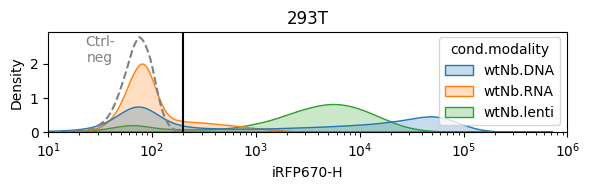

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# Threshold for iRFP670
iRFP670_H_thresh = 2e2

# Plot iRFP670-H
x = 'iRFP670-H'
hue = 'cond.modality'
hue_order = ['wtNb.DNA', 'wtNb.RNA', 'wtNb.lenti']


sns.kdeplot(data=df_all.loc[df_all[x] > 0],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(iRFP670_H_thresh, 0, 1, color='black')

# Move legend
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Title
plt.title('293T')
# Adjust limits
iRFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(iRFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-iRFP670_wtNb.svg', bbox_inches='tight')

**Figure S5D**

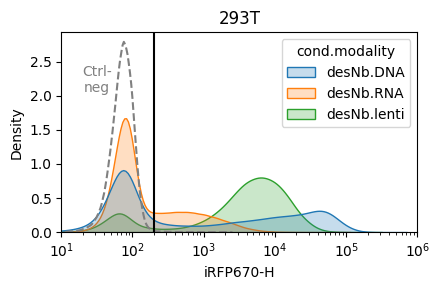

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 3))

# Plot iRFP670-H
x = 'iRFP670-H'
hue = 'cond.modality'
hue_order = ['desNb.DNA', 'desNb.RNA', 'desNb.lenti',]


sns.kdeplot(data=df_all.loc[df_all[x] > 0],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(iRFP670_H_thresh, 0, 1, color='black')

# Move legend
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Title
plt.title('293T')
# Adjust limits
iRFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(iRFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-iRFP670_desNb.svg', bbox_inches='tight')

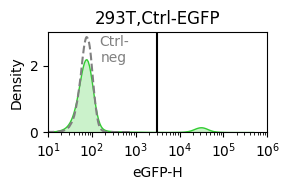

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Threshold for GFP
eGFP_H_thresh = 3*10**3

# Plot eGFP-H
x = 'eGFP-H'

# Plot Ctrl-EGFP
cond = 'Ctrl-EGFP'
sns.kdeplot(data=df_all.loc[(df_all['cond'] == cond) & (df_all[x] > 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='limegreen',
        fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_all.loc[(df_all.cond=='Ctrl-neg')& (df_all[x] > 0)],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey', legend=False)
ax.annotate('Ctrl-\nneg', (0.3, 0.7), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'293T,{cond}')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-eGFP.svg', bbox_inches='tight')

In [14]:
# Categorize cells based on iRFP670_thresh
df_all.loc[:, 'iRFP670_cat'] = 'iRFP670-'
df_all.loc[(df_all['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = ['experiment', 'modality', 'cond', 'rep']
count_df_reps = df_all.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

# Mean Dot plots

Gate positive cells by iRFP670

In [15]:
# Gate positive cells
df_positive = df_all.loc[(df_all['iRFP670_cat'] == 'iRFP670+')]

**Figure S5E**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_22304\197210839.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.axhline(float(df_gmean.loc[df_gmean.cond == 'Ctrl-neg', y+' (gmean)']), 0, 1, color='grey', linestyle='--')


                                            rep  iRFP670-H (gmean)
experiment cond     modality cond.modality                        
comparison Ctrl-neg Ctrl     Ctrl-neg.Ctrl  1.0          60.880197
           desNb    DNA      desNb.DNA      2.5        8522.760241
                    RNA      desNb.RNA      4.0         742.905161
                    lenti    desNb.lenti    2.0        5203.829362
           wtNb     DNA      wtNb.DNA       2.5       11526.716514
                    RNA      wtNb.RNA       4.0         501.562817
                    lenti    wtNb.lenti     2.0        4579.718155


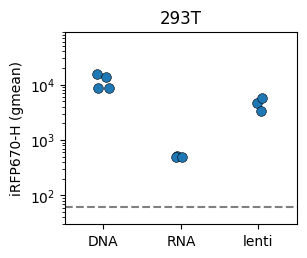

In [16]:
# Plotting params
x = 'modality'
order = ['DNA', 'RNA', 'lenti']
# label_map = {'wtNb.DNA':'DNA', 'wtNb.RNA':'RNA', 'wtNb.lenti':'lenti'}


# Calc gmean
y = 'iRFP670-H'
group = ['experiment', 'cond', 'modality', 'cond.modality', 'rep']
df_gmean = df_positive.groupby([*group])[y].apply(scipy.stats.gmean).reset_index(name=y+' (gmean)')
# Take out ctrl
df_gmean = df_gmean.loc[df_gmean.modality != 'Ctrl'] 
# Add back in ctrl
df_ctrl_gmean = df_all.loc[df_all[y]>0].groupby(group)[y].apply(scipy.stats.gmean).reset_index(name=y+' (gmean)')
df_ctrl_gmean = df_ctrl_gmean.loc[df_ctrl_gmean.cond == 'Ctrl-neg']
# Final gmean df with positive cells and ctrl neg
df_gmean = pd.concat([df_gmean, df_ctrl_gmean], ignore_index=True)


# Conditions
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Plot geometric means
cond = 'wtNb'
sns.stripplot(
    ax=ax, data=df_gmean.loc[df_gmean.cond == cond],
    x=x, y=y+' (gmean)',
    order=order,
    dodge=True, 
    size=7,
    edgecolor='black', linewidth=0.4)

# Plot ctrl-neg
ax.axhline(float(df_gmean.loc[df_gmean.cond == 'Ctrl-neg', y+' (gmean)']), 0, 1, color='grey', linestyle='--')

# # Add in stats
# # Pairs for stats comp
# pairs = [('wtNb.RNA', 'wtNb.lenti')]
# annot = Annotator(ax=ax,
#     data=df_gmean, pairs=pairs,
#     x=x, y=y,
#     order=order)
# annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='star', loc='inside', verbose=2)
# annot.apply_test().annotate(line_offset_to_group=0)


# # Adjust labels
# ax.set_xticklabels([label_map[l] for l in order])
ax.set_xlabel('')
# ax.ticklabel_format(axis='y', style='sci', scilimits=(1, 2))
ax.set_yscale('log')
ax.set_ylim((3e1, 9e4))
# ax.yaxis.set_label_text('iRFP670\n(gmean)')
# sns.move_legend(ax, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.title('293T')

print(df_gmean.groupby(['experiment', 'cond','modality', 'cond.modality']).mean())

plt.savefig(figpath/f'stripplt_iRFP670_{cond}.svg', bbox_inches='tight')

## Contours

**Figure S5F**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_22304\857987228.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


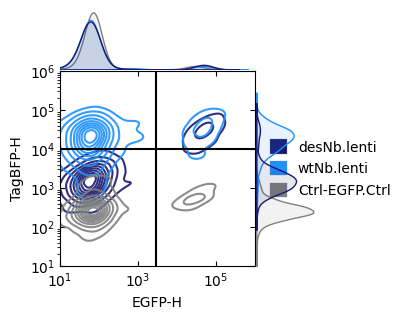

In [17]:
from matplotlib.patches import Patch
# General plotting params
x = "eGFP-H.1"
y = "TagBFP-H.1"
hue = "cond.modality"
hue_order = ['desNb.lenti', 'wtNb.lenti', 'Ctrl-EGFP.Ctrl']

# Conditions
palette = {
    'desNb.lenti': 'midnightblue',
    'wtNb.lenti': 'dodgerblue',
    'Ctrl-EGFP.Ctrl': 'grey',
}

small_data = df_positive.loc[(df_positive[x] > 0) & (df_positive[y] > 0)]
small_data = small_data.loc[(small_data.modality != 'Ctrl')]

# Add ctrl-neg back in
small_ctrl = df_all.loc[(df_all[x] > 0) & (df_all[y] > 0) & (df_all[y] < 2000)]
small_ctrl = small_ctrl.loc[small_ctrl.cond == 'Ctrl-EGFP']
small_ctrl.loc[:, "cond.modality"] = 'Ctrl-EGFP.Ctrl'

small_data = pd.concat([small_data, small_ctrl], ignore_index=True)
small_data = small_data.groupby([hue]).sample(n=1000, random_state=1)


# Definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]


# Set up figure
fig = plt.figure(figsize=(3, 3))

ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)

ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()

ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()


# Set limits
mRuby2_lim = (10, 1e6)
eGFP_lim = (10, 1e6)

ylim = mRuby2_lim
xlim = eGFP_lim

ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)

ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)


# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    alpha=0.9,
    palette=palette,
    log_scale=True,
    common_norm=False,
    fill=False,
    legend=False,
)


# Plot top histogram
sns.kdeplot(
    ax=ax_histx,
    data=small_data,
    x=x,
    hue=hue,
    hue_order=hue_order,
    alpha=0.1,
    palette=palette,
    log_scale=True,
    fill=True,
    common_norm=False,
    legend=False,
)


# Plot side histogram
sns.kdeplot(
    ax=ax_histy,
    data=small_data,
    y=y,
    hue=hue,
    hue_order=hue_order,
    alpha=0.1,
    palette=palette,
    log_scale=True,
    fill=True,
    common_norm=False,
    legend=False,
)


# Thresholds
TagBFP_H1_thresh = 1e4

ax_scatter.axvline(
    eGFP_H_thresh,
    0, 1,
    color='black'
)

ax_scatter.axhline(
    TagBFP_H1_thresh,
    0, 1,
    color='black'
)


# Axis labels
ax_scatter.set_xlabel('EGFP-H')
ax_scatter.set_ylabel('TagBFP-H')


# ---------------------------------------------------------
# Custom legend using matplotlib.patches.Patch
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=palette[condition],
        edgecolor='grey', linewidth = 0.2,
        label=condition
    )
    for condition in hue_order
]

ax_scatter.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2,
    borderaxespad=0
)


# Layout
fig.tight_layout()

plt.savefig(
    figpath / 'joint_TagBFP-H.1_vs_EGFP-H_comparison_lenti.svg',
    bbox_inches='tight'
)

## Selectivity plots

In [18]:
# Categorize cells based on TagBFP levels
df_positive['TagBFP_cat'] = np.where(df_positive["TagBFP-H.1"] > TagBFP_H1_thresh, 'TagBFP+', 'TagBFP-') 


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_22304\647053388.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive['TagBFP_cat'] = np.where(df_positive["TagBFP-H.1"] > TagBFP_H1_thresh, 'TagBFP+', 'TagBFP-')


In [19]:
df_positive['eGFP_cat'] = np.where(df_positive['eGFP-H'] > eGFP_H_thresh, 'eGFP+', 'eGFP-').copy()

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_22304\1801959318.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive['eGFP_cat'] = np.where(df_positive['eGFP-H'] > eGFP_H_thresh, 'eGFP+', 'eGFP-').copy()


In [20]:
# Get only TagBFP+
df_positive_TagBFP = df_positive.loc[df_positive['TagBFP_cat'] == 'TagBFP+'] 

# Calculate EGFP+ of TagBFP+
group = ['experiment', 'cond', 'modality', 'cond.modality', 'rep']
count_df = df_positive_TagBFP.groupby([*group, 'well', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if none rather than dropping row
df_selectivity = (count_df*100/count_df.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
# Just get eGFP+
df_selectivity = df_selectivity.loc[df_selectivity.eGFP_cat == 'eGFP+']

**Figure S5C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\3859702053.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\3859702053.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\3859702053.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


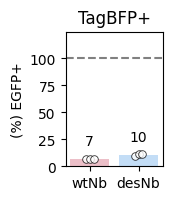

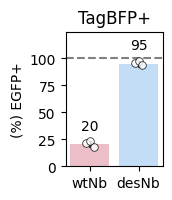

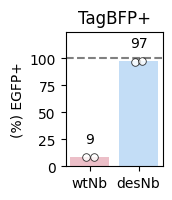

In [96]:
modality_list = ['DNA', 'RNA', 'lenti']

# General plotting params
x = 'cond'
y = 'percent'

# Conditions
order = ['wtNb', 'desNb']
palette = {'wtNb': 'crimson', 'desNb': 'dodgerblue'}

# Plot selectivity
for modality in modality_list:

    fig, ax = plt.subplots(1, 1, figsize=(1.25, 1.75))

    df_mod = df_selectivity[
        (df_selectivity.modality == modality) &
        (df_selectivity.rep != 1)
    ].copy()

    # ---------------------------------------------------------
    # Barplot in the back
    # ---------------------------------------------------------

    sns.barplot(
        ax=ax,
        data=df_mod,
        x=x,
        y=y,
        order=order,
        palette=palette,
        alpha=0.3
    )

    # ---------------------------------------------------------
    # Calculate mean percent for each biological replicate
    # ---------------------------------------------------------

    bio_means = (
        df_mod
        .groupby(['cond', 'rep'], as_index=False)['percent']
        .mean()
    )

    # ---------------------------------------------------------
    # Plot biological replicate means as dots
    # ---------------------------------------------------------

    # Small horizontal offsets so dots from the same condition
    # don't completely overlap
    unique_reps = sorted(bio_means['rep'].unique())
    rep_offsets = np.linspace(
        -0.08,
        0.08,
        len(unique_reps)
    )

    for j, rep in enumerate(unique_reps):

        rep_data = bio_means[
            bio_means['rep'] == rep
        ]

        for i, cond in enumerate(order):

            row = rep_data[
                rep_data['cond'] == cond
            ]

            if row.empty:
                continue

            ax.scatter(
                i + rep_offsets[j],
                row['percent'].iloc[0],
                s=30,
                marker='o',
                facecolor='white',
                edgecolor='black',
                linewidth=0.6,
                alpha=0.8,
                zorder=5
            )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------

    ax.set_ylim((0, 125))
    ax.set_yticks(np.arange(0, 101, 25))

    ax.yaxis.set_label_text('(%) EGFP+')
    ax.set_title('TagBFP+')
    ax.set_xlabel('')

    ax.axhline(
        100,
        0,
        1,
        color='grey',
        linestyle='--'
    )

    # ---------------------------------------------------------
    # Bar labels
    # ---------------------------------------------------------

    for sub_ax in plt.gcf().get_axes():
        for container in sub_ax.containers:

            bar_labels = sub_ax.bar_label(
                container,
                fmt='%0.0f',
                padding=8
            )

            for label in bar_labels:
                label.set_bbox(
                    dict(
                        facecolor='white',
                        alpha=0.75,
                        linewidth=0,
                        pad=1
                    )
                )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------

    plt.savefig(
        figpath / f'barplot_selectivity_{modality}.svg',
        bbox_inches='tight'
    )

**Figure S5C (with significance)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\642053093.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


DNA: wtNb vs desNb | t = -11.971, p = 4.161e-11


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\642053093.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_43616\642053093.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


RNA: wtNb vs desNb | t = -50.127, p = 3.367e-17
lenti: wtNb vs desNb | t = -179.574, p = 5.769e-09


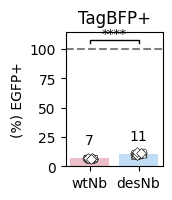

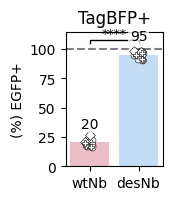

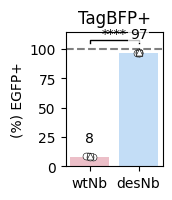

In [98]:
# General plotting params
x = 'cond'
y = 'percent'

# Conditions
order = ['wtNb', 'desNb']
palette = {'wtNb': 'crimson', 'desNb': 'dodgerblue'}

# Plot selectivity
for modality in df_selectivity.modality.unique():

    fig, ax = plt.subplots(1, 1, figsize=(1.25, 1.75))

    df_mod = df_selectivity[
        df_selectivity.modality == modality
    ].copy()

    sns.barplot(
        ax=ax,
        data=df_mod,
        x=x,
        y=y,
        order=order,
        palette=palette,
        alpha=0.3
    )

    sns.stripplot(
        ax=ax,
        data=df_mod,
        x=x,
        y=y,
        order=order,
        dodge=True,
        color='white',
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

    # Plot tech reps
    for (j, rep) in enumerate(
        data_iRFP670_percent_reps.rep.unique()
    ):
        sns.stripplot(
            ax=ax,
            data=df_mod[df_mod.rep == rep],
            x=x,
            y=y,
            order=order,
            dodge=True,
            marker=marker_list[j],
            color='white',
            size=5,
            edgecolor='black',
            linewidth=0.4,
        )

    # ---------------------------------------------------------
    # Two-sided independent Student's t-test
    # ---------------------------------------------------------

    wtNb = df_mod.loc[
        df_mod['cond'] == 'wtNb',
        y
    ].dropna()

    desNb = df_mod.loc[
        df_mod['cond'] == 'desNb',
        y
    ].dropna()

    t_stat, p_val = ttest_ind(
        wtNb,
        desNb,
        equal_var=True,
        alternative='two-sided'
    )

    print(
        f"{modality}: wtNb vs desNb | "
        f"t = {t_stat:.3f}, "
        f"p = {p_val:.4g}"
    )

    # ---------------------------------------------------------
    # Significance bracket
    # ---------------------------------------------------------

    add_sig_bracket(
        ax,
        0,
        1,
        y=105,
        h=3,
        p=p_val
    )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------

    ax.set_ylim((0, 115))
    ax.set_yticks(np.arange(0, 101, 25))

    ax.yaxis.set_label_text('(%) EGFP+')
    ax.set_title('TagBFP+')
    ax.set_xlabel('')

    ax.axhline(
        100,
        0,
        1,
        color='grey',
        linestyle='--'
    )

    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(
                i,
                fmt='%0.0f',
                padding=8
            )

            for label in bar_labels:
                label.set_bbox(
                    dict(
                        facecolor='white',
                        alpha=0.75,
                        linewidth=0,
                        pad=1
                    )
                )

    plt.savefig(
        figpath / f'barplot_selectivity_{modality}.svg',
        bbox_inches='tight'
    )